# Getting Started: Transfer Learning for Air Quality Models

This notebook demonstrates the basic workflow for transfer learning between cities.

**Scenario**: Transfer a Gaussian Process model trained on Dublin (source) to Cork (target).

In [1]:
import sys
sys.path.append('..')

import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

from src.models.gp_model import BaselineGP, train_baseline_gp, predict_with_uncertainty
from src.transfer_methods.prior_tempering import train_tempered_gp
from src.evaluation.metrics import regression_metrics, prediction_interval_coverage_probability

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Generate Synthetic Data

For demonstration, we'll create synthetic air quality data with:
- **Source domain** (Dublin): 200 samples
- **Target domain** (Cork): 50 samples (limited data!)
- **Domain shift**: Different feature distributions

In [2]:
# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Source domain (Dublin) - large dataset
n_source = 200
X_source = torch.randn(n_source, 3)
y_source = 2.0 * torch.sin(X_source[:, 0]) + 1.5 * torch.cos(X_source[:, 1]) + 0.5 * X_source[:, 2]
y_source += torch.randn(n_source) * 0.3  # Add noise

# Target domain (Cork) - small dataset with domain shift
n_target = 50
X_target = torch.randn(n_target, 3) + 0.3  # Shifted distribution
y_target = 2.0 * torch.sin(X_target[:, 0]) + 1.5 * torch.cos(X_target[:, 1]) + 0.5 * X_target[:, 2]
y_target += torch.randn(n_target) * 0.4  # Higher noise

# Test data
n_test = 100
X_test = torch.randn(n_test, 3) + 0.3
y_test = 2.0 * torch.sin(X_test[:, 0]) + 1.5 * torch.cos(X_test[:, 1]) + 0.5 * X_test[:, 2]
y_test += torch.randn(n_test) * 0.4

print(f"Source domain: {n_source} samples")
print(f"Target domain: {n_target} samples")
print(f"Test set: {n_test} samples")

Source domain: 200 samples
Target domain: 50 samples
Test set: 100 samples


## 2. Train Source Model (Dublin)

First, we train a GP on the source domain with plenty of data.

In [3]:
# Initialize and train source model
source_likelihood = gpytorch.likelihoods.GaussianLikelihood()
source_model = BaselineGP(X_source, y_source, source_likelihood)

print("Training source model (Dublin)...")
source_model, source_likelihood = train_baseline_gp(
    source_model, source_likelihood,
    X_source, y_source,
    num_iter=200,
    lr=0.1,
    verbose=True
)

print("\n✓ Source model trained successfully")

Training source model (Dublin)...
Iter 10/200 - Loss: 0.802
Iter 20/200 - Loss: 0.509
Iter 30/200 - Loss: 0.448
Iter 40/200 - Loss: 0.429
Iter 50/200 - Loss: 0.416
Iter 60/200 - Loss: 0.411
Iter 70/200 - Loss: 0.407
Iter 80/200 - Loss: 0.405
Iter 90/200 - Loss: 0.403
Iter 100/200 - Loss: 0.402
Iter 110/200 - Loss: 0.401
Iter 120/200 - Loss: 0.400
Iter 130/200 - Loss: 0.399
Iter 140/200 - Loss: 0.398
Iter 150/200 - Loss: 0.398
Iter 160/200 - Loss: 0.397
Iter 170/200 - Loss: 0.397
Iter 180/200 - Loss: 0.396
Iter 190/200 - Loss: 0.396
Iter 200/200 - Loss: 0.395

✓ Source model trained successfully


## 3. Compare Transfer Strategies

We'll compare three approaches:
1. **Baseline**: Train from scratch on target data only
2. **Full transfer** (β=1.0): Complete trust in source knowledge
3. **Tempered transfer** (β=0.5): Balanced approach

In [4]:
results = {}

# Strategy 1: Baseline (no transfer)
print("\n" + "="*60)
print("Strategy 1: Baseline (Train from Scratch)")
print("="*60)

baseline_likelihood = gpytorch.likelihoods.GaussianLikelihood()
baseline_model = BaselineGP(X_target, y_target, baseline_likelihood)
baseline_model, baseline_likelihood = train_baseline_gp(
    baseline_model, baseline_likelihood,
    X_target, y_target,
    num_iter=200,
    verbose=False
)

preds_baseline, stds_baseline = predict_with_uncertainty(
    baseline_model, baseline_likelihood, X_test
)

metrics_baseline = regression_metrics(preds_baseline, y_test.numpy())
picp_baseline = prediction_interval_coverage_probability(
    preds_baseline, stds_baseline, y_test.numpy()
)

results['baseline'] = {
    'predictions': preds_baseline,
    'uncertainties': stds_baseline,
    **metrics_baseline,
    'picp': picp_baseline
}

print(f"RMSE: {metrics_baseline['rmse']:.4f}")
print(f"MAE:  {metrics_baseline['mae']:.4f}")
print(f"R²:   {metrics_baseline['r2']:.4f}")
print(f"PICP: {picp_baseline:.2%}")


Strategy 1: Baseline (Train from Scratch)
RMSE: 0.5401
MAE:  0.4183
R²:   0.8945
PICP: 96.00%


In [5]:
# Strategy 2: Full Transfer (β=1.0)
print("\n" + "="*60)
print("Strategy 2: Full Transfer (β=1.0)")
print("="*60)

transfer_full_model, transfer_full_likelihood = train_tempered_gp(
    source_gp=source_model,
    target_x=X_target,
    target_y=y_target,
    beta=1.0,
    num_iter=200,
    verbose=False
)

preds_full, stds_full = predict_with_uncertainty(
    transfer_full_model, transfer_full_likelihood, X_test
)

metrics_full = regression_metrics(preds_full, y_test.numpy())
picp_full = prediction_interval_coverage_probability(
    preds_full, stds_full, y_test.numpy()
)

results['full_transfer'] = {
    'predictions': preds_full,
    'uncertainties': stds_full,
    **metrics_full,
    'picp': picp_full
}

print(f"RMSE: {metrics_full['rmse']:.4f}")
print(f"MAE:  {metrics_full['mae']:.4f}")
print(f"R²:   {metrics_full['r2']:.4f}")
print(f"PICP: {picp_full:.2%}")


Strategy 2: Full Transfer (β=1.0)
RMSE: 0.5109
MAE:  0.3974
R²:   0.9056
PICP: 97.00%


In [6]:
# Strategy 3: Tempered Transfer (β=0.5)
print("\n" + "="*60)
print("Strategy 3: Tempered Transfer (β=0.5)")
print("="*60)

transfer_temp_model, transfer_temp_likelihood = train_tempered_gp(
    source_gp=source_model,
    target_x=X_target,
    target_y=y_target,
    beta=0.5,
    num_iter=200,
    verbose=False
)

preds_temp, stds_temp = predict_with_uncertainty(
    transfer_temp_model, transfer_temp_likelihood, X_test
)

metrics_temp = regression_metrics(preds_temp, y_test.numpy())
picp_temp = prediction_interval_coverage_probability(
    preds_temp, stds_temp, y_test.numpy()
)

results['tempered_transfer'] = {
    'predictions': preds_temp,
    'uncertainties': stds_temp,
    **metrics_temp,
    'picp': picp_temp
}

print(f"RMSE: {metrics_temp['rmse']:.4f}")
print(f"MAE:  {metrics_temp['mae']:.4f}")
print(f"R²:   {metrics_temp['r2']:.4f}")
print(f"PICP: {picp_temp:.2%}")


Strategy 3: Tempered Transfer (β=0.5)
RMSE: 0.5116
MAE:  0.3980
R²:   0.9053
PICP: 97.00%


## 4. Visualize Results

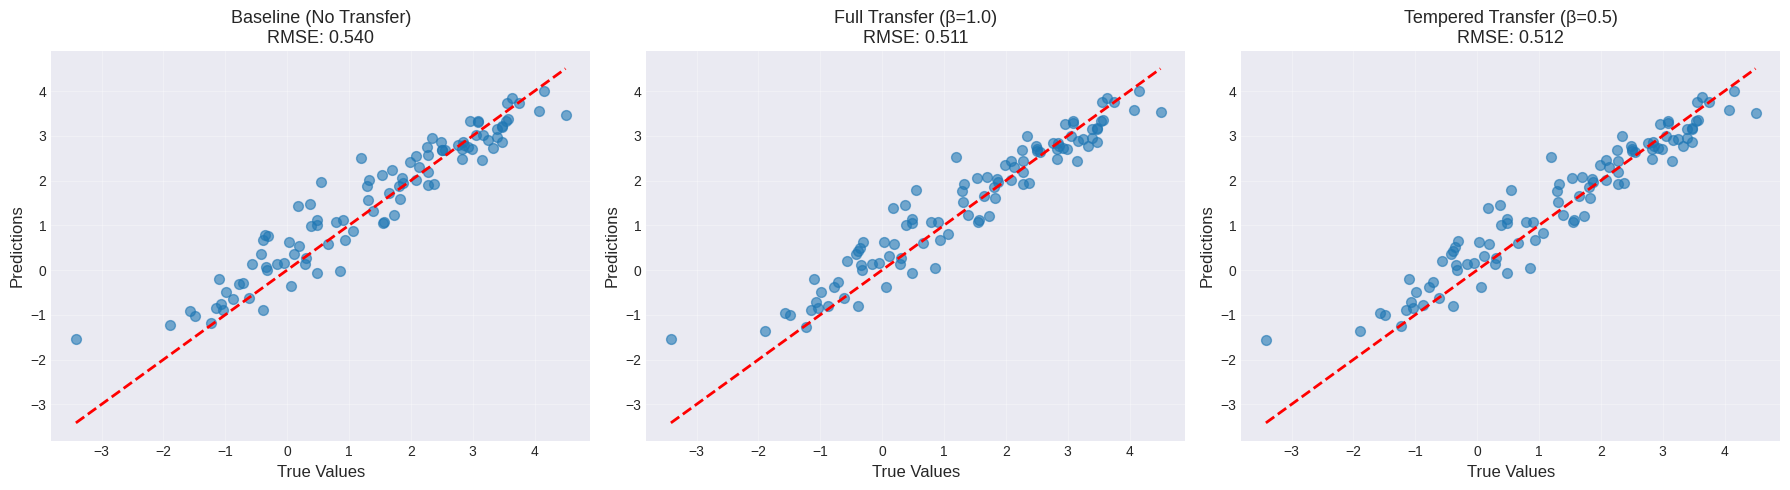

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies = ['baseline', 'full_transfer', 'tempered_transfer']
titles = ['Baseline (No Transfer)', 'Full Transfer (β=1.0)', 'Tempered Transfer (β=0.5)']

for ax, strategy, title in zip(axes, strategies, titles):
    preds = results[strategy]['predictions']
    true_vals = y_test.numpy()
    
    ax.scatter(true_vals, preds, alpha=0.6, s=50)
    min_val, max_val = true_vals.min(), true_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_xlabel('True Values', fontsize=12)
    ax.set_ylabel('Predictions', fontsize=12)
    ax.set_title(f"{title}\nRMSE: {results[strategy]['rmse']:.3f}", fontsize=13)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary

Compare all strategies:

In [8]:
import pandas as pd

summary = pd.DataFrame({
    'Strategy': ['Baseline', 'Full Transfer (β=1.0)', 'Tempered (β=0.5)'],
    'RMSE': [results['baseline']['rmse'], results['full_transfer']['rmse'], results['tempered_transfer']['rmse']],
    'MAE': [results['baseline']['mae'], results['full_transfer']['mae'], results['tempered_transfer']['mae']],
    'R²': [results['baseline']['r2'], results['full_transfer']['r2'], results['tempered_transfer']['r2']],
    'PICP': [results['baseline']['picp'], results['full_transfer']['picp'], results['tempered_transfer']['picp']]
})

print("\n" + "="*80)
print("COMPARISON OF TRANSFER STRATEGIES")
print("="*80)
print(summary.to_string(index=False))
print("\nNote: Lower RMSE/MAE is better, Higher R² is better, PICP should be ~0.95")


COMPARISON OF TRANSFER STRATEGIES
             Strategy     RMSE      MAE       R²  PICP
             Baseline 0.540127 0.418304 0.894467  0.96
Full Transfer (β=1.0) 0.510937 0.397442 0.905565  0.97
     Tempered (β=0.5) 0.511595 0.398046 0.905322  0.97

Note: Lower RMSE/MAE is better, Higher R² is better, PICP should be ~0.95


## Key Takeaways

1. **Prior tempering enables effective transfer** even with limited target data
2. **Temperature parameter β controls the balance** between source knowledge and target adaptation
3. **Uncertainty quantification** (PICP) remains well-calibrated after transfer
4. **Data efficiency**: Transfer learning reduces the need for large target datasets